In [5]:
pip install tensorflow numpy matplotlib

In [6]:
import numpy as np
import tensorflow as tf
from tensorflow.keras import layers
import matplotlib.pyplot as plt

In [7]:
def real_data(n=1000):
    return np.random.normal(0, 1, (n, 2))

In [8]:
def build_generator():
    model = tf.keras.Sequential([
        layers.Dense(16, activation='relu', input_dim=10),
        layers.Dense(32, activation='relu'),
        layers.Dense(2)
    ])
    return model

In [9]:
def build_discriminator():
    model = tf.keras.Sequential([
        layers.Dense(32, activation='relu', input_dim=2),
        layers.Dense(16, activation='relu'),
        layers.Dense(1, activation='sigmoid')
    ])
    model.compile(
        optimizer='adam',
        loss='binary_crossentropy',
        metrics=['accuracy']
    )
    return model

In [10]:
def build_gan(generator, discriminator):
    discriminator.trainable = False
    gan = tf.keras.Sequential([generator, discriminator])
    gan.compile(optimizer='adam', loss='binary_crossentropy')
    return gan

In [11]:
generator = build_generator()
discriminator = build_discriminator()
gan = build_gan(generator, discriminator)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [12]:
epochs = 5000
batch_size = 32

real = real_data()

for epoch in range(epochs):

    # Train Discriminator
    idx = np.random.randint(0, real.shape[0], batch_size)
    real_samples = real[idx]

    noise = np.random.normal(0, 1, (batch_size, 10))
    fake_samples = generator.predict(noise, verbose=0)

    X = np.vstack((real_samples, fake_samples))
    y = np.vstack((np.ones((batch_size,1)),
                   np.zeros((batch_size,1))))

    discriminator.trainable = True
    discriminator.train_on_batch(X, y)

    # Train Generator
    noise = np.random.normal(0, 1, (batch_size, 10))
    misleading_labels = np.ones((batch_size,1))

    discriminator.trainable = False
    gan.train_on_batch(noise, misleading_labels)

    if epoch % 1000 == 0:
        print(f"Epoch {epoch} completed")

Epoch 0 completed
Epoch 1000 completed
Epoch 2000 completed
Epoch 3000 completed
Epoch 4000 completed


In [13]:
noise = np.random.normal(0, 1, (500, 10))
generated_data = generator.predict(noise)

16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step


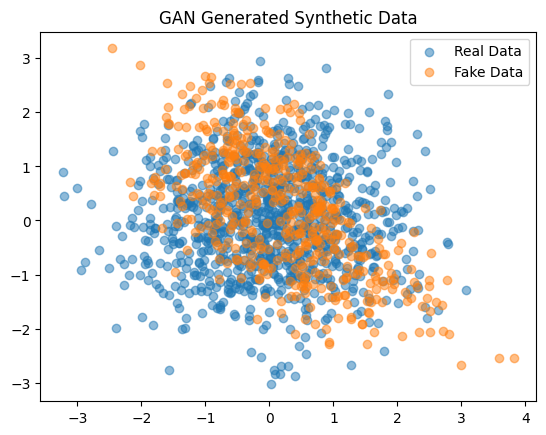

In [14]:
plt.scatter(real[:,0], real[:,1], label="Real Data", alpha=0.5)
plt.scatter(generated_data[:,0],
            generated_data[:,1],
            label="Fake Data",
            alpha=0.5)

plt.legend()
plt.title("GAN Generated Synthetic Data")
plt.show()